In [5]:
import numpy as np
from matplotlib import pyplot as plt
import qutip as qt
from qutip import tensor
from scipy import constants as co
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy 
from scipy import signal as sig
from scipy import interpolate as interp
from importlib import reload
from scipy.fft import fft, ifft, fftfreq, fftshift
import time
import pickle
#import dill
import os

#integration
import scipy.integrate as integrate

%matplotlib inline
# savePath = '/mnt/clNAS/clNumerical/Python/Arjan/Kiilerich_calcResults'

# reload(qt)
qt.about()

#A few constants and shorthands
pi = np.pi
kB = co.k
hbar = co.hbar
sqrt = np.sqrt

#some defaults parameters
kappa_ext0 = 2*pi*1e6
kappa_int0 = 0
gamma_phi0 = 0

from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Jake Lishman, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.0.3.post1
Numpy Version:      2.0.1
Scipy Version:      1.14.0
Cython Version:     None
Matplotlib Version: 3.9.1.post1
Python Version:     3.12.5
Number of CPUs:     16
BLAS Info:          Generic
INTEL MKL Ext:      False
Platform Info:      Windows (AMD64)
Installation path:  c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip
Please cite QuTiP in your publication.
For your convenience a bibtex reference can b

In [6]:
def H_res(c, cd, adu, av, Delta=0):
    Hs = Delta*cd*c
    Hu = -.5j*adu*c
    Hv = -.5j*cd*av
    Huv = -.5j*adu*av
    return Hs, Hu, Hv, Huv

In [7]:
def n_th(T, w):  #from Goto 2017, just after eq. 7
    #Adjust for the factor 2 in that equation by realizing wp = 2*w
    return 1./(np.exp(hbar*w/(kB*T))-1) 

def collapse_ops_res_step1(ck, ckd, T=0, w=2*pi*10e9, kappa_ext=kappa_ext0, 
                           kappa_int=kappa_int0, gamma_phi=gamma_phi0, noLoss=False):
    #pure dephasing
    gamphi = np.sqrt(2.*gamma_phi) #as in Kono-san's code

    if T==0:
        if noLoss:
            return [np.sqrt(kappa_ext)*ck]
        else: 
            return [np.sqrt(kappa_ext)*ck, np.sqrt(kappa_int)*ck, gamphi*ckd*ck]
    else:
        n_t = n_th(T, w)
        print('thermal occupation numbers are ', round(n_t,2))

        #external kappa
        keDown = np.sqrt(kappa_ext*(n_t+1))
        keUp = np.sqrt(kappa_ext*n_t)

        #internal kappa
        kiDown = np.sqrt(kappa_int*(n_t+1))
        kiUp = np.sqrt(kappa_int*n_t)

        if noLoss:
            return [keDown*ck, keUp*ckd]

        return [keDown*ck, kiDown*ck, kiUp*ckd, keUp*ckd, gamphi*ckd*ck]

In [8]:
def operatorPlots_res(result, tList, c, cd, au, adu, av, adv, kappa_ext, plots=False):
    #get exp. a, ad, c, cd, ada, cdc
    states = result.states
    print(states)
    purities = [(states[i]**2).tr() for i in range(len(states))]

    #real parts
    # c_s = np.real(qt.expect(c, states))
    # cd_s = np.real(qt.expect(cd, states))
    aduau_s = np.real(qt.expect(adu*au, states))
    cdc_s = np.real(qt.expect(cd*c, states))
    advav_s = np.real(qt.expect(adv*av, states))
                       
    #Lindblad term   
    LdLu = kappa_ext*cdc_s 
    
    #plot some
    if plots:
        fig, axes = plt.subplots(1,2, figsize=(12,6))        
        axes[0].plot(tList, aduau_s, label='<adu*au>')
        axes[0].plot(tList, cdc_s, label='<cd*c>')
        axes[0].plot(tList, advav_s, label='<adv*av>')
        axes[0].plot(tList, purities, label='Tr(rho^2) -- purity')
        axes[0].legend()
        axes[0].set_xlabel(r'time ($\kappa_{ext}^{-1}$)')
        axes[0].set_title('resonator operators')
       
        axes[1].plot(tList, np.real(LdLu), label='<L0us*L0usd>')
        axes[1].legend()
        axes[1].set_xlabel(r'time ($\kappa_{ext}^{-1}$)')
        axes[1].set_title('L thingie operators')
        
    return aduau_s, cdc_s, advav_s, LdLu

In [201]:
c = qt.destroy(10)
cd = c.dag()
au = qt.destroy(10)
adu = au.dag()
av = qt.destroy(10)
adv = av.dag()
gamma = 0.1  #100MHz
t_interval = 12/600 / gamma

def u(t, args):
    sigma = args["sigma"]
    tc = args["center"]
    return np.exp(-(t-tc)**2/2/sigma**2)/np.sqrt(2*np.pi*sigma**2)#*np.cos(10*2*np.pi*t)

def gu(t, args):
    gu_list = []
    u_sum = 0
    for i in range(len(t)):
        u_sum = u_sum + np.abs(u(t[i], args))**2
        
        print(u_sum * t_interval)
        gu = u(t[i], args)/np.sqrt(1-(u_sum * t_interval))
        gu_list.append(gu)
    return np.array(gu_list)

def r_res(delta, gamma):
    return (-1j*(delta)+gamma/2)/(-1j*(delta)-gamma/2)

def u_omega(t, args):
    u_omega = fft(u(t, args))
    omega_values = fftfreq(len(t), d=(t[1] - t[0]))
    u_omega_shifted = fftshift(u_omega) 
    omega_shifted = fftshift(omega_values)
    return omega_shifted, u_omega_shifted

def v(t, delta, gamma, args):
    v_omega = r_res(delta, gamma) * np.abs(u_omega(t, args)[1])
    v_t = ifft(v_omega)
    return v_t

# Hs, Hu, Hv, Huv = H_res(c, cd, adu, av, Delta=0)
# psi0 = qt.basis(10, 0)

# H = [Hs, [Hu, gu]]


3.5821058656560364e-11
7.784064920223558e-11
1.270919584559742e-10
1.84773426899046e-10
2.522739907436513e-10
3.312019833722206e-10
4.234181954506647e-10
5.310736563815793e-10
6.566527704694236e-10
8.030225199721887e-10
9.734885349303575e-10
1.1718589271790526e-09
1.4025168942197887e-09
1.6705032186858082e-09
1.9816099220899e-09
2.3424864785882396e-09
2.760760156905444e-09
3.2451722377102014e-09
3.805732051063223e-09
4.453890995627967e-09
5.202738939781886e-09
6.067225666328022e-09
7.064410309015433e-09
8.21374204245666e-09
9.537375629298382e-09
1.1060525801763044e-08
1.2811864861124464e-08
1.4823968320577669e-08
1.713381389665204e-08
1.978333967419797e-08
2.2820067832502643e-08
2.6297800927748144e-08
3.0277398382324396e-08
3.4827641536963e-08
4.0026196379758474e-08
4.5960683879343514e-08
5.2729868720164095e-08
6.0444978168243e-08
6.92311637881712e-08
7.922911978830471e-08
9.059687289303245e-08
1.0351175983002605e-07
1.1817260977778633e-07
1.3480215044540394e-07
1.536496578526831e-07
1

(0.0, 8.0)

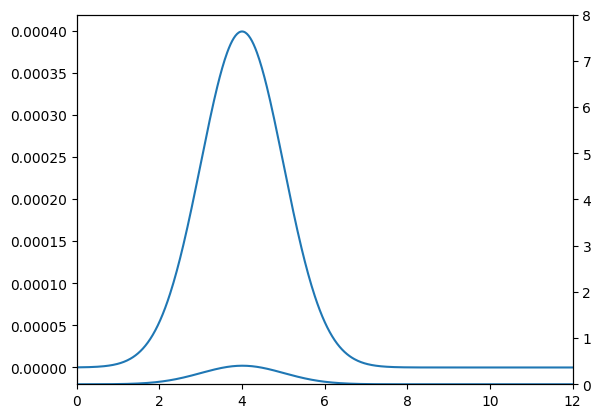

In [208]:

tList = np.linspace(0, 12, 601) / gamma
u_args = {'sigma':1/ gamma , 'center':4/ gamma}
# delta = u_omega(tList, u_args)[0]
# gamma = 50*np.pi
fig, ax1 = plt.subplots()
ax1.set_xlim(0 , 12)
ax1.plot(tList* gamma, u(tList, u_args) * 1e-2)
# ax1.set_ylim(-0.8 , 0.8)
ax2 = ax1.twinx()
ax2.plot(tList* gamma, gu(tList, u_args)/ gamma)
ax2.set_ylim(0, 8)
# plt.plot(delta, r_res(delta, gamma) * np.abs(u_omega(tList, u_args)[1]))
# plt.plot(tList, v(tList, delta, gamma, u_args))

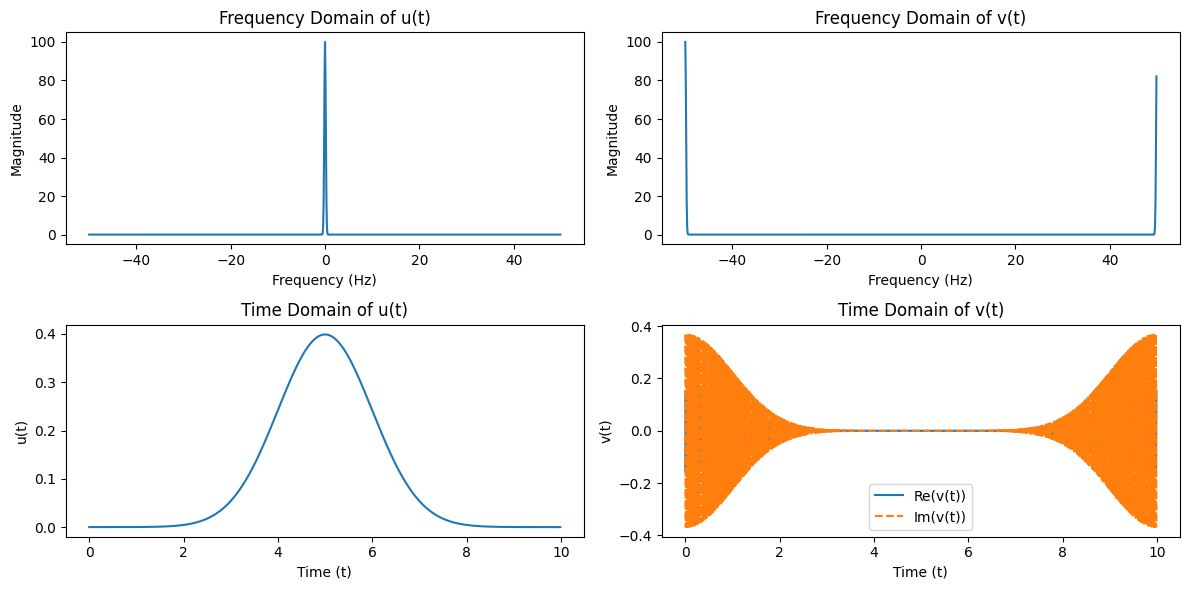

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift

# ガウス関数
def u(t, args):
    sigma = args["sigma"]
    tc = args["center"]
    return np.exp(-(t-tc)**2/2/sigma**2)/np.sqrt(2*np.pi*sigma**2)

# レゾナンス関数
def r_res(delta, gamma):
    return (-1j*(delta) + gamma/2) / (-1j*(delta) - gamma/2)

# フーリエ変換関数
def u_omega(t, args):
    u_omega = fft(u(t, args))
    omega_values = fftfreq(len(t), d=(t[1] - t[0]))
    u_omega_shifted = fftshift(u_omega) 
    omega_shifted = fftshift(omega_values)
    return omega_shifted, u_omega_shifted

# 時間領域の信号
def v(t, delta, gamma, args):
    omega, u_omega_shifted = u_omega(t, args)
    v_omega = r_res(delta, gamma) * np.abs(u_omega_shifted)
    v_t = ifft(v_omega)
    return omega, u_omega_shifted, np.real(v_t), np.imag(v_t)

# 時間軸の定義
t_interval = 0.01
t = np.arange(0, 10, t_interval)

# 引数の設定
args = {
    "sigma": 1.0,
    "center": 5.0
}

# パラメータの設定
delta = 1.0
gamma = 3

# `u(t)`のフーリエ変換結果
omega_u, u_omega_shifted = u_omega(t, args)

# `v(t)`の計算
omega, u_omega_shifted, v_t_real, v_t_imag = v(t, delta, gamma, args)

# グラフの描画
plt.figure(figsize=(12, 6))

# `u(t)`の周波数領域
plt.subplot(2, 2, 1)
plt.plot(omega, np.abs(u_omega_shifted))
plt.title('Frequency Domain of u(t)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

# `v(t)`の周波数領域
plt.subplot(2, 2, 2)
plt.plot(omega, np.abs(fftshift(r_res(delta, gamma) * np.abs(u_omega_shifted))))
plt.title('Frequency Domain of v(t)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

# `u(t)`の時間領域
plt.subplot(2, 2, 3)
plt.plot(t, u(t, args))
plt.title('Time Domain of u(t)')
plt.xlabel('Time (t)')
plt.ylabel('u(t)')

# `v(t)`の時間領域
plt.subplot(2, 2, 4)
plt.plot(t, v_t_real, label='Re(v(t))')
plt.plot(t, v_t_imag, label='Im(v(t))', linestyle='--')
plt.title('Time Domain of v(t)')
plt.xlabel('Time (t)')
plt.ylabel('v(t)')
plt.legend()

plt.tight_layout()
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_17268\3766940006.py:19: RuntimeWarning: invalid value encountered in sqrt
  gu = u(t[i], args)/np.sqrt(1-(u_sum * t_interval))


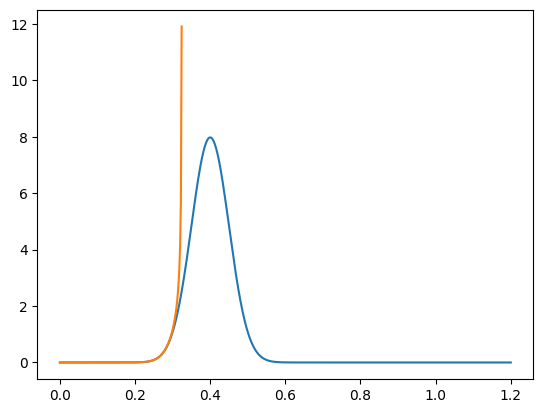

In [ ]:






kappa_ext = 2*pi*1e6
kappa_int = 0
gamma_phi = 0

collapses = collapse_ops_res(ck, ckd, T=0, w=2*pi*10e9, kappa_ext=kappa_ext, 
                                    kappa_int=kappa_int, gamma_phi=gamma_phi, noLoss=True)
   
args = {'center':500e-9}
result = qt.mesolve(H, psi0, tList, collapses , [], args=args)  


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1689843324.py, line 9)

[Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]], Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 9.99999903e-01-7.12859758e-31j -1.95262100e-11+3.11360021e-04j
  -6.86237644e-08-9.54855063e-15j  1.84773472e-18-1.37197511e-11j
   1.55649171e-15+4.75085753e-22j -1.89332454e-26+2.69438033e-19j
  -7.81538652e-24-1.79529224e-32j  1.62596516e-42-5.69938887e-30j
   4.12817165e-40+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-1.95262100e-11-3.11360021e-04j  9.70486583e-08+9.38974790e-31j
  -1.06679014e-18+2.37633060e-11j -3.11298343e-15-4.75085753e-22j
  

(array([ 0.00000000e+00, -1.95262115e-11, -7.81840840e-11, -1.76107029e-10,
        -3.13435513e-10, -4.90312584e-10, -7.06900047e-10, -9.63357196e-10,
        -1.25984163e-09, -1.59651243e-09, -1.97357148e-09, -2.39121565e-09,
        -2.84962771e-09, -3.34899047e-09, -3.88951092e-09, -4.47142468e-09,
        -5.09495589e-09, -5.76033585e-09, -6.46780304e-09, -7.21760316e-09,
        -8.00999267e-09, -8.84523766e-09, -9.72360952e-09, -1.06453874e-08,
        -1.16108584e-08, -1.26203172e-08, -1.36740703e-08, -1.47724335e-08,
        -1.59157286e-08, -1.71042858e-08, -1.83384436e-08, -1.96185489e-08,
        -2.09449616e-08, -2.23180510e-08, -2.37381934e-08, -2.52057734e-08,
        -2.67211850e-08, -2.82848307e-08, -2.98971281e-08, -3.15585041e-08,
        -3.32693930e-08, -3.50302383e-08, -3.68414934e-08, -3.87036210e-08,
        -4.06170994e-08, -4.25824167e-08, -4.46000705e-08, -4.66705692e-08,
        -4.87944321e-08, -5.09721900e-08, -5.32043846e-08, -5.54915693e-08,
        -5.7

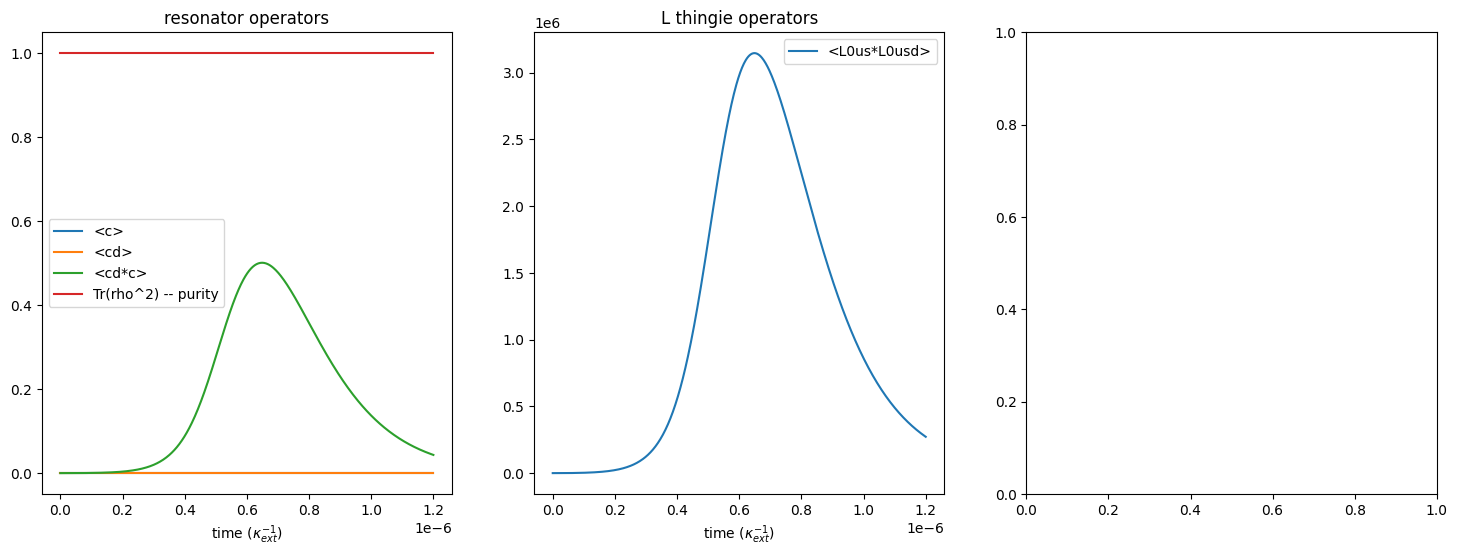

In [ ]:
operatorPlots_res(result, tList, ck, ckd, kappa_ext, plots=True)

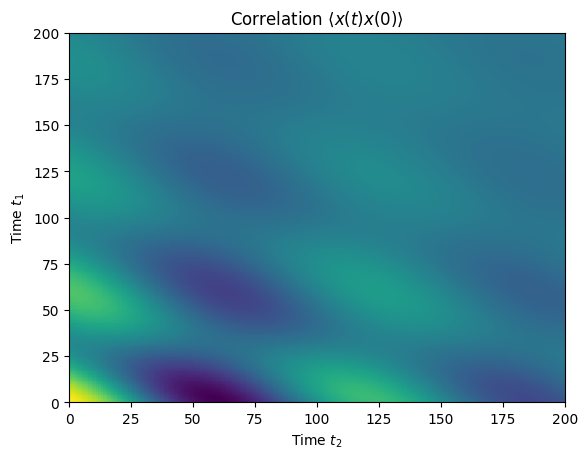

In [363]:
import numpy as np
import pylab as plt
from qutip import *

times = np.linspace(0, 10.0, 200)
a = destroy(10)
x = a.dag() + a
H = a.dag() * a
alpha = 2.5
rho0 = coherent_dm(10, alpha)
corr = correlation_2op_2t(H, rho0, times, times, [np.sqrt(0.25) * a], x, x)

plt.pcolor(np.real(corr))
plt.xlabel(r'Time $t_2$')
plt.ylabel(r'Time $t_1$')
plt.title(r'Correlation $\left<x(t)x(0)\right>$')
plt.show()

from Arjan-san

In [209]:
'''
#test the above
tList = np.arange(0, 1e-6, 1e-9)
gaussArgs = {'sigma':10e-9, 'tCenter':100e-9}
y = uGauss(tList, gaussArgs)

gt = g_u(tList, uGauss, args_u=gaussArgs, returnFunc=False)
gFunc = g_u(tList, uGauss, args_u=gaussArgs)
y3 = np.abs(gauss60(tList))**2 


fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(tList, y, label='y')
axes[0].plot(tList, gFunc(tList), label='g_u(t)')
#axes[0].plot(tList, denom)
axes[0].legend()
'''


"\n#test the above\ntList = np.arange(0, 1e-6, 1e-9)\ngaussArgs = {'sigma':10e-9, 'tCenter':100e-9}\ny = uGauss(tList, gaussArgs)\n\ngt = g_u(tList, uGauss, args_u=gaussArgs, returnFunc=False)\ngFunc = g_u(tList, uGauss, args_u=gaussArgs)\ny3 = np.abs(gauss60(tList))**2 \n\n\nfig, axes = plt.subplots(1,2, figsize=(15,5))\naxes[0].plot(tList, y, label='y')\naxes[0].plot(tList, gFunc(tList), label='g_u(t)')\n#axes[0].plot(tList, denom)\naxes[0].legend()\n"

In [210]:
def uGauss(t, args):
    tCenter = args['tCenter']
    sigma = args['sigma']
    prefactor = 1./(np.sqrt(sigma)*(pi**(1./4)))
    return prefactor*np.exp((-1*(t-tCenter)**2)/(2*sigma**2))

In [239]:
#resonator operators
NF_res = 4
NF_output = 2
NF_input = 4

ID_res = qt.identity(NF_res)
ID_output = qt.identity(NF_output)
ID_input =qt.identity(NF_input)

#input pulse
au = qt.destroy(NF_input)
aud = au.dag()

#resonator
c = qt.destroy(NF_res)
cd = c.dag()

#operators - subspaces: output
av = qt.destroy(NF_output)
avd = av.dag()

#operators: total space
au_input = qt.tensor([au, ID_res])#, ID_output])
aud_input= au_input.dag() 

c_res = qt.tensor([ID_input, c])#, ID_output])
cd_res = c_res.dag()
                      
av_output = qt.tensor([ID_input, ID_res])#, av])
avd_output = av_output.dag()

print(av_output.dims, au_input.dims, c_res.dims)
print(avd_output.dims, aud_input.dims, cd_res.dims)

#default driveArgs:
driveFuncArgs = {'tCenter':100e-9, 'sigma':15e-9}
gaussArgs = {'driveFunc':uGauss, 'driveFuncArgs':driveFuncArgs}

kappa_int0 = 0
kappa_ext0 = 1
gamma_phi0 = 0

[[4, 4], [4, 4]] [[4, 4], [4, 4]] [[4, 4], [4, 4]]
[[4, 4], [4, 4]] [[4, 4], [4, 4]] [[4, 4], [4, 4]]


In [267]:
def makeDrive(tList, DriveArgs):
    '''
    Same as makeLPFDrive, but more apt name
    '''
    
    #Get some input func arguments from the dict
    driveFunc = DriveArgs['driveFunc']
    driveArgs = DriveArgs['driveFuncArgs']
    
    #construct input:
    tList_highRes = np.linspace(tList[0], tList[-1], 5000)
    inputAmps = driveFunc(tList_highRes, **driveArgs)
    print('Created the filtered input pulse')
    
    def p_func(t, args): return inputAmps(t)  
    
    print('in makeDrive, outputs are ', p_func, inputAmps)
    
    return p_func, inputAmps

In [411]:
#Write down the Hamiltonian: 
def HL_res(w, kappa_ext):
    #H0 = hbar*w*cd_res*c_res #Should be multiplied by hbar!
    H0 = 0*cd_res*c_res
    Hgu_c= .5j*np.sqrt(kappa_ext)*(aud_input*c_res) #to be multiplied with g*(t)
    Hgu = -.5j*np.sqrt(kappa_ext)*(au_input*cd_res) #to be multiplied with g(t)
    return H0, Hgu_c, Hgu

def uInput(tList, tCenter, tau):
    return (1./(np.sqrt(tau)*np.pi**.25))*np.exp((-(tList-tCenter)**2)/(2*tau**2))

#First, just switch it on linearly, followed by an exponential curve
def H1_coeff_g_gaussInput(t, args):
   
    tCenter= args['tCenter']
    sigma = args['sigma'] 
    amp=args['Amp']
    func_u = args['func_u']
    
    ys, func = g_u(t, amp*func_u(t, tCenter, sigma), returnFunc=False)
    
    return ys

#First, just switch it on linearly, followed by an exponential curve
def H1_coeff_g_gaussInputConj(t, args):
   
    tCenter= args['tCenter']
    sigma = args['sigma'] 
    amp=args['Amp']
    
    ys, func = g_u(t, u, returnFunc=False)
    
    return np.conj(ys)

def g_u_wrapper(tlist, args):
    func_u = args['driveFunc']
    args_u = args['driveFuncArgs']
    return g_u(tlist, func_u, args_u, returnFunc=True)

#based on Eq 10 in Kiilerich 2020
def solveHLTTime(tlist, psi0, Ht, collapses, T=.02, w0=0, 
                 kappa_ext=1, kappa_int=0, gamma_phi=0,
                 driveArgs=gaussArgs, plotDrive=True,
                 pulseFunc=None, pulseFuncConj=None, verbose=True):
    if verbose: print('in SolveHLTTime, driveArgs are ', driveArgs)
    
    driveArgs = driveArgs['driveFuncArgs']
    print('drive parrameters', driveArgs)
    if plotDrive:
        fig, axes = plt.subplots()
        axes.plot(tList, pulseFunc(tList, gaussArgs), label='pulseFunc & collapse func')
        axes.plot(tList, pulseFuncConj(tList, gaussArgs), label='pulseFuncConj')
        axes.legend()
        axes.set_title('drive functions in solveHLTTime')
        
        print('kappas, gammas in solveHLTTime are ', kappa_ext, kappa_int, gamma_phi)

    # Ht = [H0, [Hgu_c, gu_func2_conj], [Hgu, gu_func2]] 
    result = qt.mesolve(Ht, psi0, tlist, collapses , [], args=driveArgs)
    return result  



def g_u(ts, func_u, args_u={}, returnFunc=True, conjugate=False):
    '''
    u is a waveform that is supposed to be normalized (int(|u|^2) = 1), and that has time as its only variable
    
    ts is a list of times here. We try to calculate all times at once for speed
    '''
    
    def u(t): return func_u(t, args_u)

    if not type(ts) == float:
        #test normalization of u(t)
        intU = integrate.quad(lambda t: np.abs(u(t))**2, min(ts), max(ts))
    
        print('normalization: int(|u|^2) = ', intU, ' over the defined time domain')
        if intU[0]-1 >.001:
            print('u is not normalized')
            return
    
    ut = u(ts)
    eps = 1e-14

    #slower method
    denom2 = np.array([integrate.quad(lambda t: np.abs(u(t))**2, min(ts), t)[0] for t in ts])
    denomtot2 = np.sqrt(1-denom2+eps)
    g_t = np.conjugate(ut)/denomtot2   
    
    if conjugate:
        g_t = np.conjugate(g_t)
           
    if returnFunc:
        interpFunc = interp.interp1d(ts, g_t, bounds_error=False, fill_value=0)
        return interpFunc
    else:
        return g_t
    
#Note this definition is a lot different from the ones I use in the other calculations! Sigma is far off!
def uGauss(t, args):
    tCenter = args['tCenter']
    sigma = args['sigma']
    prefactor = 1./(sigma * np.sqrt(2 * np.pi))
    return prefactor*np.exp((-1*(t-tCenter)**2)/(2*sigma**2))

#define a gaussian shape of 60ns at 500ns:
def gauss60(t): return uGauss(t, {'tCenter':500e-9, 'sigma':60e-9})

In [412]:
def transformMatrixK(AB, BdAd):
    #code by Marek Pechal
    #Note I need to know both A(t+tau)B(t) AND Bd(t)Ad(t+tau) for this
    #ABNew = np.zeros(np.shape(AB), dtype='complex64')
    
    if AB is BdAd:
        print('AB is BdAd')
        for i in range(AB.shape[0]):
            AB[i, i:] = AB[i, :AB.shape[1]-i]
            AB[i, :i] = AB[:i, i].conjugate()
        return AB, AB
    
    else:
        print('AB is not BdAd')
        for i in range(AB.shape[0]):
            AB[i,i:] = AB[i, :AB.shape[1]-i]
            BdAd[i,i:] = BdAd[i, :BdAd.shape[1]-i]
            AB[i, :i] = BdAd[:i, i].conjugate()
            BdAd[i, :i] = AB[:i, i].conjugate()
        return AB, BdAd

def autoCorrelations(Ht, psi0, tList, collapses, gu_func, gu_func_conj, kappa_ext, plotComps=True):
    '''
    correlation_2op_2t(H, state0, tlist, taulist, c_ops, a_op, b_op, 
    solver='me', reverse=False, args={}, options=<qutip.solver.Options object>)
    
    Calculate the two-operator two-time correlation function: ⟨A(t+τ)B(t)⟩ along 
    two time axes using the quantum regression theorem and the evolution solver 
    indicated by the solver parameter.
    
    Returns:
    corr_matndarray

        An 2-dimensional array (matrix) of correlation values for the times specified by 
        tlist (first index) and taulist (second index). If tlist is None, 
        then a 1-dimensional array of correlation values is returned instead.
        
    '''

    print('calculating correlation functions')
    
    ada = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, aud_input, au_input, reverse=True)
    adc = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, aud_input, c_res, reverse=True) 
    cda = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, cd_res, au_input, reverse=True)
    cdc = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, cd_res, c_res, reverse=True)
    
    #LdLOne = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, 
    #                               cd_res, c_res)
      
    fourPanelPlot(np.real(ada), np.real(adc), np.real(cda),  np.real(cdc), 
                      'ada', 'adc', 'cda', 'cdc')
        
    #prefactors
    print('calculating prefactor matrices')
    ID = np.ones((len(tList), len(tList)))
    ID1 = np.ones(len(tList))
    kappas2 = kappa_ext*ID
    kappag = np.outer(np.sqrt(kappa_ext)*ID1, gu_func(tList))
    gkappa = np.outer(gu_func_conj(tList), np.sqrt(kappa_ext)*ID1)
    #gg = np.outer(gu_func(tList), gu_func_conj(tList))
    gg = np.outer(gu_func_conj(tList), gu_func(tList))
    
    #Use eq 9. Then <Ld(t) L(t')> = < ((gu_conj(t)au(t)+sqrt(y)c)^d) * {gu(t')au(t')+sqrt(y)c(t')) >}
    # = < ((gu_(t)au_d(t)+sqrt(y)c_d) * {gu(t')au(t')+sqrt(y)c(t')) >
    # = gu(t) gu(t') * aud*ad  + gu(t)*sqrt(y) aud*c + gu(t')sqrt(y)*au*cd + y*cd*c
    LdL = gg*ada  + gkappa*adc + kappag*cda + kappas2*cdc
    
    print('transforming matrices')
    #Use the commutation relations to get aad, ccd
    adac = ada.conjugate()
    cdcc = cdc.conjugate()

    adar = transformMatrixK(1*ada, adac)[0]
    cdcr = transformMatrixK(1*cdc, cdcc)[0]
    
    #for adc, to calculate the reform, I need <cdadd> = <cda>*, which I have
    adcr = transformMatrixK(1*adc, 1*cda.conjugate())[0]
    cdar = transformMatrixK(1*cda, 1*adc.conjugate())[0]
    print('after matrix transform\n')
    
    adar, adcr, cdar, cdcr = np.array(adar), np.array(adcr), np.array(cdar), np.array(cdcr)
    
    #no transform
    #adar, adcr, cdar, cdcr = ada, adc, cda, cdc
    
    print('tList len ', len(tList))
    print('gg shape',  np.shape(gg))
    print('adar shape ', np.shape(adar))
    LdLr =  gg*adar +  gkappa*adcr +  kappag*cdar + kappas2*cdcr
    
    #This one should be wrong
    LdLr2 =  gg*adar +  kappag*adcr +  gkappa*cdar + kappas2*cdcr
    
    #plot coeff matrices
    print('plotting coefs')
    fig, axes = plt.subplots(2,2, figsize=(12,12))
    im00 = axes[0][0].imshow(np.real(kappas2))
    axes[0][0].set_title('kappas')
    im10 = axes[1][0].imshow(np.real(gkappa))
    axes[1][0].set_title('gkappa')
    im01 = axes[0][1].imshow(np.real(kappag))
    axes[0][1].set_title('kappag')
    im11 = axes[1][1].imshow(np.real(gg))
    axes[1][1].set_title('gg')
    
    #colorbars
    plt.colorbar(im00, ax=axes[0][0])
    plt.colorbar(im01, ax=axes[0][1])
    plt.colorbar(im10, ax=axes[1][0])
    plt.colorbar(im11, ax=axes[1][1])
    
    if plotComps:
        fourPanelPlot(np.real(gg*adar), np.real(gkappa*adcr), np.real(kappag*cdar),  np.real(kappas2*cdcr), 
                      'gg*adar', 'kappag*adcr', 'kappag*cdar', 'kappas2*cdcr')
        fourPanelPlot(np.real(LdL), np.real(kappag*adcr), np.real(gkappa*cdar),  np.real(LdLr2), 
                      'LdL (unrotated)', 'gkappa*adc', 'gkappa*cdar', 'LdLr2')
        fourPanelPlot(np.real(ada), np.real(adc), np.real(cda),  np.real(cdc), 
                      'ada', 'adc', 'cda', 'cdc')

    
   
    print('plotting autoCorrs')
    plotAutoCorrellations(adar, adcr, cdar, cdcr, LdLr, suffix='r')
    
    return ada, adc, cda, cdc, LdL, adar, adcr, cdar, cdcr, LdLr

def plotAutoCorrellations(ada, adc, cda, cdc, LdL, suffix='', plotImag=False, plotAbs=False):

    #real values
    fourPanelPlot(np.real(ada), np.real(adc), np.real(cda),  np.real(cdc), 
                  'real(ada'+suffix+')', 'real(adc'+suffix+')', 'real(cda'+suffix+')', 'real(cdc'+suffix+')' )
    
    if plotImag:
        #imag values
        fourPanelPlot(np.imag(ada), np.imag(adc), np.imag(cda),  np.imag(cdc), 
                      'imag(ada'+suffix+')', 'imag(adc'+suffix+')', 'imag(cda'+suffix+')', 'imag(cdc'+suffix+')' )


    if plotAbs:
        fourPanelPlot(np.abs(ada), np.abs(adc), np.abs(cda),  np.abs(cdc), 
                     'abs(ada'+suffix+')', 'abs(adc'+suffix+')', 'abs(cda'+suffix+')', 'abs(cdc'+suffix+')' )
        
   
    #LdL plots
    fig2, axes2 = plt.subplots(1,3, figsize=(18,12))
    im20 = axes2[0].imshow(np.abs(LdL))
    axes2[0].set_title('abs(<L^{dagger}(t+tau)L(t)>')
    plt.colorbar(im20, ax=axes2[0])
    im21 = axes2[1].imshow(np.real(LdL))
    axes2[1].set_title('real(<L^{dagger}(t+tau)L(t)>')
    plt.colorbar(im21, ax=axes2[1])
    im22 = axes2[2].imshow(np.imag(LdL))
    axes2[2].set_title('imag(<L^{dagger}(t+tau)L(t)>')
    plt.colorbar(im22, ax=axes2[2])
      
    return

def fourPanelPlot(d1, d2, d3, d4, title1, title2, title3, title4):
    
    fig, axes = plt.subplots(2,2, figsize=(12,12))
    im00 = axes[0][0].imshow(d1)
    axes[0][0].set_title(title1)
    im10 = axes[1][0].imshow(d2)
    axes[1][0].set_title(title2)
    im01 = axes[0][1].imshow(d3)
    axes[0][1].set_title(title3)
    im11 = axes[1][1].imshow(d4)
    axes[1][1].set_title(title4)
    
    #colorbars
    plt.colorbar(im00, ax=axes[0][0])
    plt.colorbar(im01, ax=axes[0][1])
    plt.colorbar(im10, ax=axes[1][0])
    plt.colorbar(im11, ax=axes[1][1])
    
    plt.show()
    
     

In [416]:
def emptyRes(tList, psi0, driveArgs=gaussArgs, w0=2*pi*10e9, T=.01, kappa_ext=kappa_ext0, gamma_phi=gamma_phi0,
            plotCollapse=True):
     
    
    #construct drive and collapse functions
    inputFunction = driveArgs['driveFunc']
    driveFuncArgs = driveArgs['driveFuncArgs']
    print('drive func args dict is ', driveFuncArgs)
    #gu_y, gu_func = g_u(tlist, inputFunction, args_u=driveFuncArgs) 
    
    #pre-make the g_u function, otherwise it tries to do it every single time
    gu_func = g_u(tList, inputFunction, args_u=driveFuncArgs, returnFunc=True)
    gu_func_conj = g_u(tList, inputFunction, args_u=driveFuncArgs, returnFunc=True, conjugate=True)
    
    #Now adapt gu_func such that it can take t, args, compatible with mesolve
    def gu_func2(t, args): return gu_func(t)
    def gu_func2_conj(t, args): return gu_func_conj(t)

    fig, axes = plt.subplots()
    axes.plot(tList, gu_func(tList), label='gu_func2')
    axes.plot(tList, gu_func_conj(tList), label='gu_func2_conj')
    axes.set_title('p_func in simKPO_step1To3')
    axes.set_xlabel('time ($\kappa_{ext}^{-1}$)')
    axes.grid()
    axes.legend()
    plt.show()
    #set up the hamiltonian and collapse operators
    H0, Hgu_c, Hgu = HL_res(w0, kappa_ext)
    Ht = [H0, [Hgu_c, gu_func2_conj(tList, driveFuncArgs)], [Hgu, gu_func2(tList, driveFuncArgs)]]   #H1_Coeff is the linear thingie
    #Ht = [(Ht1, gu_func2), (Ht2, gu_func2_conj)]   #H1_Coeff is the linear thingie
    collapses = collapse_ops_res(w=w0, kappa_ext=kappa_ext, kappa_int=0, gamma_phi=gamma_phi,
                            collapse_func=gu_func2(tList, driveFuncArgs))
    if plotCollapse:
        fig, axes = plt.subplots()
        axes.plot(tList, gu_func2(tList, gaussArgs))
        axes.set_title('plotCollapse in emptyRes')
        print('kappas are ', kappa_ext, gamma_phi)
    #solve hamiltonian
    print('Ht is ',len(Ht))
    # resultRes = solveHLTTime(tList, psi0, Ht, collapses, driveArgs=gaussArgs, pulseFunc=gu_func2, pulseFuncConj=gu_func2_conj,
    #                         kappa_ext=kappa_ext, gamma_phi=gamma_phi)
    result = qt.mesolve(Ht, psi0, tList, collapses , [], args=driveFuncArgs)
    print('resultRes is ', result)
    
    #plot some operators
    operatorPlots(result, tList, g_func=gu_func, g_func_conj=gu_func_conj, plots=True)
    
    #calculate autocorrelation
    gu_values_conj = gu_func2_conj(tList, driveFuncArgs)
    gu_values = gu_func2(tList, driveFuncArgs)
    print('+++++++++++++++++++++++++++++++')
    def sqrt_kappa_constant(t, args): return np.sqrt(kappa_ext)

    # ada = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, aud_input, au_input, reverse=True)
    print(len(gu_values_conj), len(gu_values))
    print(len(tList))
    Ht = [H0, [Hgu_c, gu_func2_conj(tList, driveFuncArgs)], [Hgu, gu_func2(tList, driveFuncArgs)]] 
    collapses =  [[c_res, sqrt_kappa_constant]] # [au_input, gu_func2(tList, driveFuncArgs)], [c_res, sqrt_kappa_constant]
    ada = qt.correlation_2op_2t(Ht, psi0, tList, tList, collapses, aud_input, au_input, reverse=True, args=driveFuncArgs)
    ada, adc, cda, cdc, ldl,  adar, adcr, cdar, cdcr, LdLr = autoCorrelations(Ht, psi0, tList, collapses, gu_func, gu_func_conj, kappa_ext)
    print('plotting auto corrs')
        
    return result, ada, adc, cda, cdc, ldl,  adar, adcr, cdar, cdcr, LdLr

def collapse_ops_res(T=0.01, w=2*pi*10e9, kappa_ext=kappa_ext0, kappa_int=kappa_int0, gamma_phi=gamma_phi0, 
                     collapse_func=H1_coeff_g_gaussInput, plotCollapse=True):
    #keDown = np.sqrt(kappa_ext)
    gamphi = np.sqrt(gamma_phi) #pure dephasing as defined in the paper

    if plotCollapse:
        fig, axes = plt.subplots()
        ts = np.linspace(0, 15, 100)
        axes.plot(ts, collapse_func)
        axes.set_title('collapse operator function in collapse_ops')
    
    def sqrt_kappa_constant(t, args): return np.sqrt(kappa_ext)
        
    return [#kiUp*cd_res, keUp*cd_res,
            #gamphi*cd_res*c_res, [(au_input, collapse_func), (c_res, sqrt_kappa_constant)]]
            # gamphi*cd_res*c_res, [[au_input, collapse_func], [c_res, sqrt_kappa_constant]]]
            #gamphi*cd_res*c_res, np.sqrt(kappa_ext0)*c_res, 
            [au_input, collapse_func], [c_res, sqrt_kappa_constant]]
            #gamphi*cd_res*c_res, np.sqrt(kappa_ext0)*c_res, 
            #[(au_input, collapse_func), (c_res, sqrt_kappa_constant)]]
    
def operatorPlots(result, tList, g_func=uGauss, g_func_conj=uGauss, kappa_ext=kappa_ext0, plots=False):
    
    #get exp. a, ad, c, cd, ada, cdc
    states = result.states
    
    #input operators
    au_s = qt.expect(au_input, states)
    aud_s = qt.expect(aud_input, states)
    audau_s = qt.expect(aud_input*au_input, states)  
    
    #resonator expects
    c_s = qt.expect(c_res, states)
    cd_s = qt.expect(cd_res, states)
    cdc_s = qt.expect(cd_res*c_res, states)
    
    #output operators
    av_s = qt.expect(av_output, states)
    avd_s = qt.expect(avd_output, states)
    avdav_s = qt.expect(avd_output*av_output, states)
                  
    audc_s = qt.expect(aud_input*c_res, states)
    aucd_s = qt.expect(au_input*cd_res, states)
    
    #Lindblad term   
    Lds = g_func_conj(tList)*aud_s + np.sqrt(kappa_ext)*cd_s
    Ls = g_func(tList)*au_s + np.sqrt(kappa_ext)*c_s
    LdLu = g_func(tList)*g_func_conj(tList)*audau_s + kappa_ext*cdc_s + np.sqrt(kappa_ext)*(g_func(tList)*audc_s + g_func_conj(tList)*aucd_s)
    
    #Remove this! Makes no sense!
    #LdLu.conjugate()
    
    #plot some
    if plots:
        fig, axes = plt.subplots(1,5, figsize=(17,6))
        
        print('plotting expectation values')        
        axes[0].plot(tList, au_s, label='<au>')
        axes[0].plot(tList, aud_s, label='<aud>')
        axes[0].plot(tList, audau_s, label='<aud*au>')
        axes[0].legend()
        axes[0].set_title('input operators')
        
        axes[1].plot(tList, c_s, label='<c>')
        axes[1].plot(tList, cd_s, label='<cd>')
        axes[1].plot(tList, cdc_s, label='<cd*c>')
        axes[1].legend()
        axes[1].set_title('resonator operators')
        
        axes[2].plot(tList, av_s, label='<a>')
        axes[2].plot(tList, avd_s, label='<ad>')
        axes[2].plot(tList, avdav_s, label='<ad*a>')
        axes[2].legend()
        axes[2].set_title('output operators')
                
        axes[3].plot(tList, LdLu, label='<L0us*L0usd>')
        axes[3].legend()
        axes[3].set_title('L thingie operators')

        axes[4].plot(tList, audau_s, label='<audau>')
        axes[4].plot(tList, cdc_s, label='<cdc>')
        axes[4].plot(tList, avdav_s, label='<avd_av>')
        axes[4].legend()
        axes[4].set_title('au, c, av')

        
    return av_s, avd_s, avdav_s, c_s, cd_s, cdc_s, au_s, aud_s, audau_s
  
def highestEigFuncsRes2(tList, g1, nMax=10, plotAll=False, plotAbs=False, returnFuncs=True):
    
    #diagonalize
    eigvals, eigvecs = scipy.linalg.eigh(g1, type=1)
    
    #normalize eigenvalues
    #eigvals = (eigvals**2)/(np.sum(eigvals**2))
    eigvals = eigvals/(np.sum(eigvals))
    print('eivals sum is ', np.sum(eigvals))
    print('eivals sum squared is ', np.sum(eigvals**2))
    
    noRows = int(np.shape(g1)[0]/10)
    print('noRows =  ', noRows)
   
    
    if plotAll:
        fig4, axes4 = plt.subplots(noRows,2, figsize=(20,300))
        fig4.suptitle('Before Sorting') 
        for i in range(noRows):

            for k in range(10):
                axes4[i][0].plot(np.real(eigvecs[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(eigvals[i]))
                axes4[i][1].plot(np.imag(eigvecs[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(eigvals[i]))
                axes4[i][0].set_xlabel('time ($\kappa_{ext}^{-1}$)')
                axes4[i][1].set_xlabel('time ($\kappa_{ext}^{-1}$)')
                axes4[i][0].legend()
                
     
    #Sort by size of eigenvalue
    sortOrder = np.argsort(np.real(eigvals))[::-1] #this sorts by real value, probably
    valsSorted = eigvals[sortOrder]
    vecsSorted = eigvecs[:, sortOrder]

    
    #plotting
    fig, axes = plt.subplots(figsize=(8,6))
    styles = ['b', 'r--', 'g.', 'k-.', 'p', '', '', '', '', '']
    for i in range(nMax):
        axes.plot(tList, np.real(vecsSorted[:,i]),  styles[i], label='eigVal '+str(i)+ ' = '+str(valsSorted[i]))
        axes.legend()
        axes.set_title('real mode shape')  
        axes.set_xlabel('time ($\kappa_{ext}^{-1}$)')
        
    if plotAbs:
        fig2, axes2 = plt.subplots(figsize=(8,6))
        styles = ['b', 'r--', 'g.', 'k-.', 'p', '', '', '', '', '']
        for i in range(nMax):
            axes2.plot(tList, np.abs(vecsSorted[:,i]),  styles[i], label='eigVal '+str(i)+ ' = '+str(valsSorted[i]))
            axes2.legend()
            axes2.set_title('abs mode shape') 
            axes.set_xlabel('time ($\kappa_{ext}^{-1}$)')

    if plotAll:
        fig3, axes3 = plt.subplots(noRows,1, figsize=(20,300))
        fig3.suptitle('After sorting')
        for i in range(noRows):
            for k in range(10):
                axes3[i].plot(tList, np.real(vecsSorted[:,10*i+k]), label='eigVal#'+str(10*i+k)+'_'+str(valsSorted[i]))
                axes3[i].legend()
                axes.set_xlabel('time ($\kappa_{ext}^{-1}$)')
                
    if returnFuncs:
        eigenModes = []
        for i in range(nMax):
            #make interp functions
            eigenModes.append(interp.interp1d(tList, vecsSorted[:,i],  kind='cubic'))
    return eigenModes


<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:176: SyntaxWarning: invalid escape sequence '\k'
<>:177: SyntaxWarning: invalid escape sequence '\k'
<>:194: SyntaxWarning: invalid escape sequence '\k'
<>:203: SyntaxWarning: invalid escape sequence '\k'
<>:212: SyntaxWarning: invalid escape sequence '\k'
<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:176: SyntaxWarning: invalid escape sequence '\k'
<>:177: SyntaxWarning: invalid escape sequence '\k'
<>:194: SyntaxWarning: invalid escape sequence '\k'
<>:203: SyntaxWarning: invalid escape sequence '\k'
<>:212: SyntaxWarning: invalid escape sequence '\k'
C:\Users\qipe\AppData\Local\Temp\ipykernel_17268\1062883377.py:23: SyntaxWarning: invalid escape sequence '\k'
  axes.set_xlabel('time ($\kappa_{ext}^{-1}$)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_17268\1062883377.py:176: SyntaxWarning: invalid escape sequence '\k'
  axes4[i][0].set_xlabel('time ($\kappa_{ext}^{-1}$)')
C:\Users\qipe\AppData\Local\Temp\ipykernel_17268\106

normalization: int(|u|^2) =  (0.9403159725795941, 2.9047503628867866e-11)  over the defined time domain
psi0 type is  ket
drive func args dict is  {'tCenter': 4.0, 'sigma': 0.3}
normalization: int(|u|^2) =  (0.9403159725795941, 2.9047503628867866e-11)  over the defined time domain
normalization: int(|u|^2) =  (0.9403159725795941, 2.9047503628867866e-11)  over the defined time domain


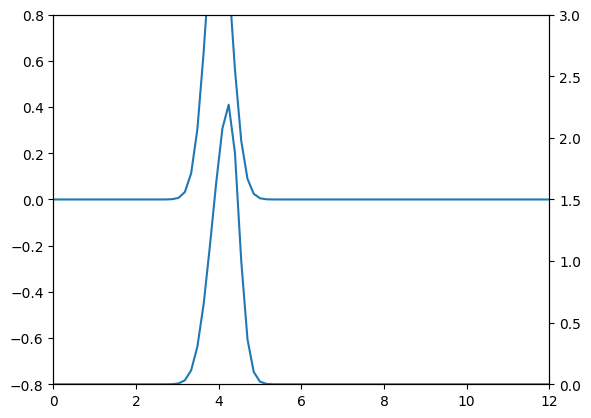

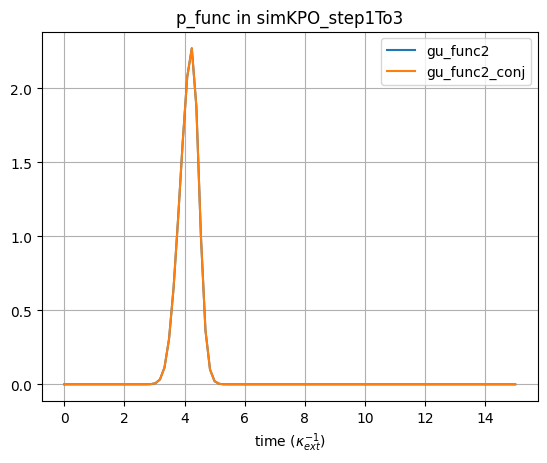

kappas are  1 1.5
Ht is  3
resultRes is  <Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0
    preparation time: 0.0
    run time: 0.014004707336425781
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 15.0] (100 steps)
  Number of e_ops: 0
  States saved.
>
plotting expectation values
+++++++++++++++++++++++++++++++
100 100
100


ValueError: tlist must be the same len as the array to interpolate

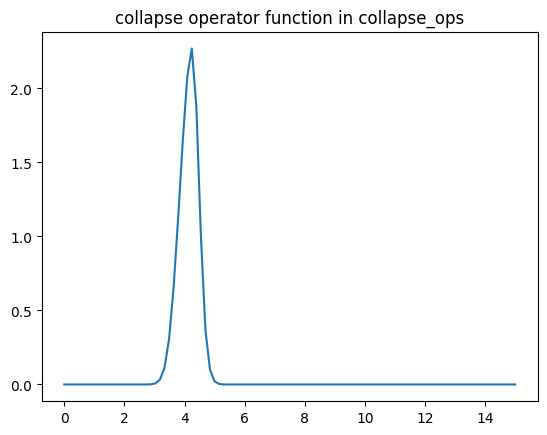

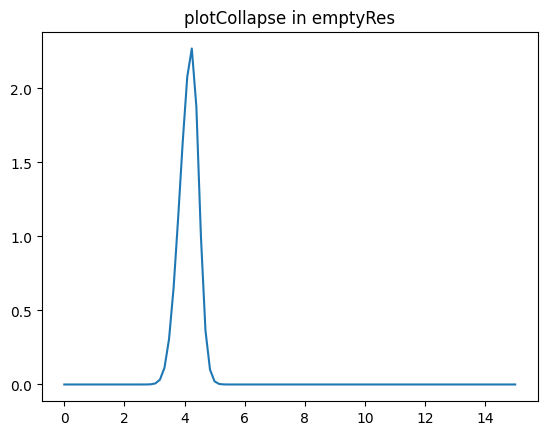

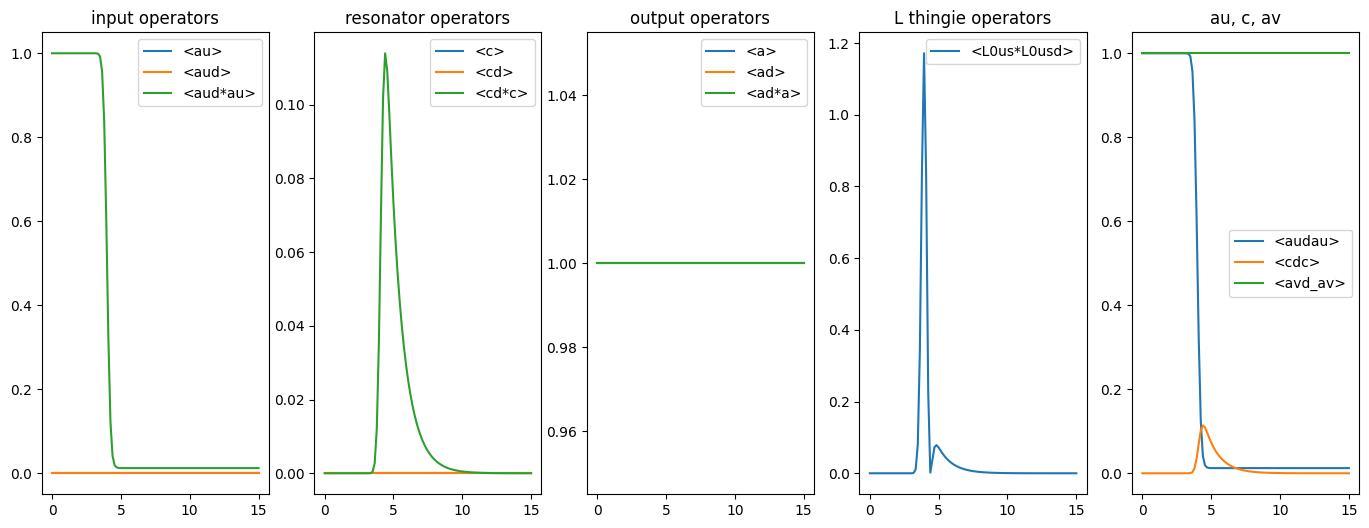

In [420]:
kappa_ext0 = 1
sigma = 1./kappa_ext0

tList = np.linspace(0, 15*1./kappa_ext0, 100)
driveFuncArgs = {'tCenter':4./kappa_ext0, 'sigma':.3*sigma}
gaussArgs = {'driveFunc':uGauss, 'driveFuncArgs':driveFuncArgs}

gu_func = g_u(tList, gaussArgs['driveFunc'], args_u=gaussArgs['driveFuncArgs'], returnFunc=True)

#plot drive and g_u
fig1, axes1 = plt.subplots()
axes1.plot(tList, uGauss(tList, driveFuncArgs), label='pulse shape u(t)')
axes1.set_xlim(0.0, 12)
axes1.set_ylim(-0.8, 0.8)
axes2 = axes1.twinx()
axes2.plot(tList, gu_func(tList), label='coupling function g_u(t)')
axes2.set_ylim(0, 3)

psi0 = qt.tensor(qt.basis(NF_input, 1), qt.basis(NF_res,0))#, qt.basis(NF_output,0))
print('psi0 type is ', psi0.type)

res, ada, adc, cda, cdc, LdL,  adar, adcr, cdar, cdcr, LdLr = emptyRes(tList, psi0, driveArgs=gaussArgs, 
                    w0=100*kappa_ext0, kappa_ext=kappa_ext0, gamma_phi=1.5*kappa_ext0)

# plotAutoCorrellations(adar, adcr, cdar, cdcr, LdLr)

# eigenModes, v0t, gv1_kpo, gv1c_kpo = get_v_and_gv(tList, LdL, nMax=5)

In [ ]:

#eigenModes, v0t, gv1_kpo, gv1c_kpo = get_v_and_gv(tList, LdL, nMax=5)


#get v1
nMax = 4
eigenModes = highestEigFuncsRes(tList, LdL, nMax=nMax)

fig, axes = plt.subplots()
for i in range(nMax):
    axes.plot(tList, np.real(eigenModes[i](tList)), label='real(n'+str(i)+')')
    axes.plot(tList, np.imag(eigenModes[i](tList)), label='imag(n'+str(i)+')')
axes.set_xlabel('time $\kappa^{-1}$')
axes.legend()

<>:12: SyntaxWarning: invalid escape sequence '\k'
<>:12: SyntaxWarning: invalid escape sequence '\k'
C:\Users\qipe\AppData\Local\Temp\ipykernel_17268\2632921270.py:12: SyntaxWarning: invalid escape sequence '\k'
  axes.set_xlabel('time $\kappa^{-1}$')


NameError: name 'highestEigFuncsRes' is not defined

In [ ]:

#get v1
nMax = 4
eigenModes = highestEigFuncsRes2(tList, LdL, nMax=nMax)

fig, axes = plt.subplots()
for i in range(nMax):
    axes.plot(tList, np.real(eigenModes[i](tList)), label='real(n'+str(i)+')')
    axes.plot(tList, np.imag(eigenModes[i](tList)), label='imag(n'+str(i)+')')
axes.set_xlabel('time $\kappa^{-1}$')
axes.legend()